In [18]:
# Import necessary libraries
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [21]:
# User Input Parameters (CHANGE)
date_str = "20260224"  # YYYYMMDD format
start_time = "000000"  # HHMMSS format
end_time = "235959"  # HHMMSS format

# Optional: Set end_time_mask to limit x-axis display (set to None to disable)
# end_time_mask = "145200"  # HHMMSS format - cuts off display at this time
end_time_mask = end_time # for full-day plots

# Base path for acoustic data
base_path = "/Users/xylu/Desktop/Data/acoustic_vpp/"

# Convert strings to datetime objects for filtering
date_obj = datetime.strptime(date_str, "%Y%m%d")
start_time_obj = datetime.strptime(date_str + start_time, "%Y%m%d%H%M%S")
end_time_obj = datetime.strptime(date_str + end_time, "%Y%m%d%H%M%S")

# Convert mask time if provided
if end_time_mask is not None:
    end_time_mask_obj = datetime.strptime(date_str + end_time_mask, "%Y%m%d%H%M%S")
else:
    end_time_mask_obj = None

print(f"Date: {date_str}")
print(f"Time range: {start_time} - {end_time}")
print(f"Start: {start_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End: {end_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")
if end_time_mask_obj:
    print(f"Display mask: {end_time_mask_obj.strftime('%Y-%m-%d %H:%M:%S')}")
    
# Load CSV files for the specified date
print("\n" + "="*60)
print("Looking for CSV files...")
print("="*60)

# Direct path: files are stored in /acoustic_vpp/YYYYMMDD/
date_folder = os.path.join(base_path, date_str)

if not os.path.exists(date_folder):
    print(f"⚠ Folder not found: {date_folder}")
    filtered_df = None
else:
    print(f"✓ Found folder: {date_folder}")
    
    # Find all CSV files matching the date pattern
    csv_files = sorted(glob.glob(os.path.join(date_folder, f"{date_str}*.csv")))
    print(f"  Found {len(csv_files)} CSV file(s)")
    
    if len(csv_files) == 0:
        print(f"⚠ No CSV files found matching {date_str}*.csv")
        filtered_df = None
    else:
        # Load and combine all CSV files
        all_data = []
        
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
                # Convert time_datetime to datetime if it's a string (handles microseconds)
                if 'time_datetime' in df.columns:
                    df['time_datetime'] = pd.to_datetime(df['time_datetime'], format='ISO8601')
                all_data.append(df)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df)} samples")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if all_data:
            # Combine all data
            combined_df = pd.concat(all_data, ignore_index=True)
            combined_df = combined_df.sort_values('time_datetime').reset_index(drop=True)
            
            print(f"\n✓ Combined data: {len(combined_df)} total samples")
            print(f"  Time range: {combined_df['time_datetime'].min()} to {combined_df['time_datetime'].max()}")
            
            # Filter by time range
            mask = (combined_df['time_datetime'] >= start_time_obj) & (combined_df['time_datetime'] <= end_time_obj)
            filtered_df = combined_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered data (between {start_time_obj.strftime('%H:%M:%S')} and {end_time_obj.strftime('%H:%M:%S')}): {len(filtered_df)} samples")
            
            if len(filtered_df) > 0:
                print(f"  Vpp range: {filtered_df['vpp_volts'].min():.4f} - {filtered_df['vpp_volts'].max():.4f} V")
            else:
                print("  ⚠ No data after filtering by time range")
        else:
            print("⚠ No data loaded!")
            filtered_df = None
            
        
# # Plot Vpp vs Time
# if filtered_df is not None and len(filtered_df) > 0:
#     fig, ax = plt.subplots(figsize=(14, 6))
    
#     ax.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], linewidth=1, label='Vpp')
#     ax.set_xlabel("Time")
#     ax.set_ylabel("Vpp (Volts)")
#     ax.set_title(f"CH3 Vpp vs Time ({date_str})\n{start_time} - {end_time} ({len(filtered_df)} samples)")
#     ax.grid(True, alpha=0.3)
#     ax.legend()
    
#     # Format x-axis
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
#     ax.tick_params(axis='both', labelsize=12)
#     plt.xticks(rotation=45)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print statistics
#     print("\n" + "="*60)
#     print("Data Statistics")
#     print("="*60)
#     print(f"Min Vpp: {filtered_df['vpp_volts'].min():.4f} V")
#     print(f"Max Vpp: {filtered_df['vpp_volts'].max():.4f} V")
#     print(f"Mean Vpp: {filtered_df['vpp_volts'].mean():.4f} V")
#     print(f"Median Vpp: {filtered_df['vpp_volts'].median():.4f} V")
#     print(f"Std Dev: {filtered_df['vpp_volts'].std():.4f} V")
#     print(f"Total samples: {len(filtered_df)}")
#     print(f"Duration: {(filtered_df['time_datetime'].max() - filtered_df['time_datetime'].min()).total_seconds()} seconds")
# else:
#     print("No data to plot!")

Date: 20260224
Time range: 000000 - 235959
Start: 2026-02-24 00:00:00
End: 2026-02-24 23:59:59
Display mask: 2026-02-24 23:59:59

Looking for CSV files...
✓ Found folder: /Users/xylu/Desktop/Data/acoustic_vpp/20260224
  Found 288 CSV file(s)
  ✓ 20260224_000000_n_vpp.csv: 6000 samples
  ✓ 20260224_000500_n_vpp.csv: 6000 samples
  ✓ 20260224_001000_n_vpp.csv: 6000 samples
  ✓ 20260224_001500_n_vpp.csv: 6000 samples
  ✓ 20260224_002000_n_vpp.csv: 6000 samples
  ✓ 20260224_002500_n_vpp.csv: 6020 samples
  ✓ 20260224_003000_n_vpp.csv: 6000 samples
  ✓ 20260224_003500_n_vpp.csv: 6000 samples
  ✓ 20260224_004000_n_vpp.csv: 6000 samples
  ✓ 20260224_004500_n_vpp.csv: 6000 samples
  ✓ 20260224_005000_n_vpp.csv: 6000 samples
  ✓ 20260224_005500_n_vpp.csv: 6000 samples
  ✓ 20260224_010000_n_vpp.csv: 6000 samples
  ✓ 20260224_010500_n_vpp.csv: 6000 samples
  ✓ 20260224_011000_n_vpp.csv: 6000 samples
  ✓ 20260224_011500_n_vpp.csv: 6000 samples
  ✓ 20260224_012000_n_vpp.csv: 6000 samples
  ✓ 202602

In [22]:
# Define friendly name mapping (from multi_plot_add_acoustic.ipynb)
pv_mapping = [
    # --- Vacuum Pressure Sensors ---
    ("VALCCG:D01_L01A:PRES", "VAC_D01L01A"),
    ("VALCCG:D01_L02:PRES", "VAC_D01L02"),
    ("VALCCG:D01_L03:PRES", "VAC_D01L03"),
    ("VALCCG:D01_L04:PRES", "VAC_D01L04"),
    ("VALCCG:D04_L01:PRES", "VAC_D4L01"),
    ("VALCCG:D04_L02:PRES", "VAC_D4L02"),
    ("VALCCG:D04_L03:PRES", "VAC_D4L03"),
    ("VALCCG:D04_L04:PRES", "VAC_D4L04"),
    ("VALCCG:D04_L05:PRES", "VAC_D4L05"),
    ("VALCCG:D04_L06:PRES", "VAC_D4L06"),
    ("VALCCG:D04_L07:PRES", "VAC_D4L07"),
    ("VALCCG:D04_L08:PRES", "VAC_D4L08"),
    ("VALCCG:D04_L09:PRES", "VAC_D04L09"),
    ("VALCCG:D05_L18:PRES", "VAC_D05L18"),
    ("VALCCG:D05_L20:PRES", "VAC_D05L20"),
    ("VALCCG:D05_L21:PRES", "VAC_D05L21"),
    ("VALCCG:D05_L22:PRES", "VAC_D05L22"),
    ("VALCCG:D05_L22A:PRES", "VAC_D05L22A"),
    ("VALCCG:D05_L23:PRES", "VAC_D05L23"),
    ("VALCCG:D05_L24:PRES", "VAC_D05L24"),
    ("VALCCG:D05_L25:PRES", "VAC_D05L25"),
    ("VALCCG:D05_L26:PRES", "VAC_D05L26"),
    ("VALCCG:D07_L0:PRES", "VAC_D07L0"),
    ("VALCCG:D07_L00:PRES", "VAC_D07L00"),
    ("VALCCG:D07_L01:PRES", "VAC_D07L01"),
    ("VALCCG:D07_L02:PRES", "VAC_D07L02"),
    ("VALCCG:D07_L03:PRES", "VAC_D07L03"),
    ("VALCCG:D07_L04:PRES", "VAC_D07L04"),
    ("VALCCG:D07_L05:PRES", "VAC_D07L05"),
    ("VALCCG:D07_L05A:PRES", "VAC_D07L05A"),
    ("VALCCG:D07_L06:PRES", "VAC_D07L06"),
    ("VALCCG:D07_L07:PRES", "VAC_D07L07"),
    ("VALCCG:D07_L08:PRES", "VAC_D07L08"),
    ("VALCCG:D07_L09:PRES", "VAC_D07L09"),
    ("VALCCG:D07_L10:PRES", "VAC_D07L10"),
    ("VALCCG:D07_L11:PRES", "VAC_D07L11"),
    ("VALCCG:D10_L01:PRES", "VAC_D10L01"),
    ("VALCCG:D10_L02:PRES", "VAC_D10L02"),
    ("VALCCG:D10_L03:PRES", "VAC_D10L03"),
    ("VALCCG:D10_L04:PRES", "VAC_D10L04"),
    ("VALCCG:D10_L05:PRES", "VAC_D10L05"),
    ("VALCCG:D10_L06:PRES", "VAC_D10L06"),
    ("VALCCG:D10_L07:PRES", "VAC_D10L07"),
    ("VALCCG:D10_L08:PRES", "VAC_D10L08"),
    ("VALCCG:D11_L18:PRES", "VAC_D11L18"),
    ("VALCCG:D11_L19:PRES", "VAC_D11L19"),
    ("VALCCG:D11_L20:PRES", "VAC_D11L20"),
    ("VALCCG:D11_L21:PRES", "VAC_D11L21"),
    ("VALCCG:D11_L22:PRES", "VAC_D11L22"),
    ("VALCCG:D11_L23:PRES", "VAC_D11L23"),
    ("VALCCG:D11_L24:PRES", "VAC_D11L24"),

    # --- Radiation and Detectors ---
    ("B2_VXD:Rad:Res:BPATDCU3:A1:DoseRate", "B_DMD_DoseRate"),
    ("B2_VXD:Rad:QCS_FW_225:DoseRate", "B_DMD_QCS_FW_225"),
    ("B2_VXD:Rad:QCS_FW_135:DoseRate", "B_DMD_QCS_FW_135"),
    ("B2_CDC:CUR:LOGGER:L15_2:MAX", "B_CDC_Imax_uA"),
    ("B2_CDC:CUR_AVERAGE", "B_CDC_Iavg_uA"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32", "B_PMThits_Hz"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32_60", "B_PMThits_avg60s"),
    ("B2_nsm:get:TRGOSCILLO0:lff_ler", "B_ECL_BG_duration_ms"),
    ("B2_nsm:get:ECLTRG_FAM:rate_bw", "B_ECL_BW"),

    # --- Beam Parameters and Injection ---
    ("B2_nsm:get:ECL_LUM_MON:lum_acc_20", "A_LUMI_30"),
    ("CG_OPR:SpecificLuminosity", "A_LUMI_SP_30"),
    ("BMLDCCT:CURRENT", "A_BM_Current_mA"),
    ("BMLDCCT:RATE", "A_BM_Inj_Rate_mAps"),
    ("BMLDCCT:LIFE", "A_BM_Lifetime_min"),
    ("CGLOPT:IP:BETA_Y", "A_BM_BetaY_IP_m"),
    ("CGLOPT:IP:BETA_X", "A_BM_BetaX_IP_m"),
    ("BMLXRM:BEAM:SIGMAX", "A_BM_SigmaX_IP_um"),
    ("BMLXRM:BEAM:SIGMAY", "A_BM_SigmaY_IP_um"),
    ("CG_OPT:CAP:SIGMAY", "A_BM_CapSigmaY_um"),
    ("BTpBPM:QMD11P_K_1:NC_1Hz:C", "A_Qep_BT_end_nC"),
    ("LIiBM:SP_61_8_1:ISNGL:KBP", "A_Qep_Linac_end_nC"),
    ("CGLINJ:EFFICIENCY", "A_INJ_Effi"),
    ("LIiEV:BEAM_REP:READ:KBP", "A_INJ_Rep_ep_Hz"),
    ("CGLINJ:KICKER:HEIGHT_R", "A_INJ_Kicker_Height_mm"),
    ("CGLINJ:KICKER:JUMP_R", "A_INJ_Kicker_Jump"),
    ("CGLINJ:SEPTUM:POS_R", "A_INJ_Septum_Pos_mm"),
    ("CGLINJ:SEPTUM:ANG_R", "A_INJ_Septum_Ang_mm"),
    ("LIiRF:MOPS:SET_PHASE:LER", "A_INJ_Phase"),
    ("CGLINJ:INJECTION:YPOS", "A_INJ_PosY_m"),
    ("CGLINJ:INJECTION:YANG", "A_INJ_AngY_rad"),
    ("BMLD07:INJ:X", "A_INJ_D7_BPMX_mm"),
    ("BMLD07:INJ:Y", "A_INJ_D7_BPMY_mm"),
    ("BMLD07:INJ:Q", "A_INJ_D7_Charge"),
    ("VALCLM:D06CV1TOP:RQ:SET_POS", "A_D6V1_TOP_Head_Pos_Set"),
    ("VALCLM:D06CV1TOP:ST:POS", "A_D6V1_TOP_Head_Pos_Meas"),
    ("VALCLM:D06CV1BTM:RQ:SET_POS", "A_D6V1_BTM_Head_Pos_Set"),
    ("VALCLM:D06CV1BTM:ST:POS", "A_D6V1_BTM_Head_Pos_Meas"),
    ("BML:MQTAFOP1:POS.PXP", "A_D6V1_Upstrm_BPM_PosX"),
    ("BML:MQTAFOP1:POS.PYP", "A_D6V1_Upstrm_BPM_PosY"),
    ("BML:MQT3FOP1:POS.PXP", "A_D6V1_Downstrm_BPM_PosX"),
    ("BML:MQT3FOP1:POS.PYP", "A_D6V1_Downstrm_BPM_PosY"),
    ("BM_BLM:BTCBT:ADC:MEAN", "A_INJ_Loss_Monitor"),

    # --- Acoustic Sensors ---
    ("RFLAE:D06:OSC1:CH1:MIN", "ACOU_Top_Min"),
    ("RFLAE:D06:OSC1:CH1:MAX", "ACOU_Top_Max"),
    ("RFLAE:D06:OSC1:CH1:VPP", "ACOU_Top_Vpp"),
    ("RFLAE:D06:OSC1:CH2:MIN", "ACOU_BmLoss_Min"),
    ("RFLAE:D06:OSC1:CH2:MAX", "ACOU_BmLoss_Max"),
    ("RFLAE:D06:OSC1:CH2:VPP", "ACOU_BmLoss_Vpp"),
    ("RFLAE:D06:OSC1:CH3:MIN", "ACOU_Btm_Min"),
    ("RFLAE:D06:OSC1:CH3:MAX", "ACOU_Btm_Max"),
    ("RFLAE:D06:OSC1:CH3:VPP", "ACOU_Btm_Vpp")
]

# Create mapping dictionary for fast lookup
pv_dict = {k: v for k, v in pv_mapping}

# Function to get friendly name or return original column name if not found
def get_friendly_name(col_name):
    return pv_dict.get(col_name, col_name)

print(f"Loaded {len(pv_mapping)} PV name mappings")

# Load machine data from Machine subfolder
machine_folder = os.path.join(base_path, date_str, "Machine")

if not os.path.exists(machine_folder):
    print(f"⚠ Machine folder not found: {machine_folder}")
    machine_df = None
else:
    print(f"✓ Found Machine folder: {machine_folder}")
    
    # Find CSV files in Machine folder
    machine_csv_files = sorted(glob.glob(os.path.join(machine_folder, "*.csv")))
    
    if len(machine_csv_files) == 0:
        print(f"  ⚠ No CSV files found in Machine folder")
        machine_df = None
    else:
        print(f"  Found {len(machine_csv_files)} machine data file(s)")
        
        # Load and combine all machine data files
        machine_data_list = []
        
        for csv_file in machine_csv_files:
            try:
                df_temp = pd.read_csv(csv_file)
                # Convert Timestamp to datetime
                if 'Timestamp' in df_temp.columns:
                    df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'], format='ISO8601')
                machine_data_list.append(df_temp)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df_temp)} samples, {len(df_temp.columns)} columns")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if machine_data_list:
            # Combine all machine data
            machine_df = pd.concat(machine_data_list, ignore_index=True)
            machine_df = machine_df.sort_values('Timestamp').reset_index(drop=True)
            
            # Rename Timestamp to time_datetime for consistency
            machine_df.rename(columns={'Timestamp': 'time_datetime'}, inplace=True)
            
            # Rename columns to friendly names
            machine_df.rename(columns=get_friendly_name, inplace=True)
            
            print(f"\n✓ Combined machine data: {len(machine_df)} samples")
            print(f"  Time range: {machine_df['time_datetime'].min()} to {machine_df['time_datetime'].max()}")
            print(f"  Columns ({len(machine_df.columns)}): {list(machine_df.columns)}")
            
            # Filter by time range
            mask = (machine_df['time_datetime'] >= start_time_obj) & (machine_df['time_datetime'] <= end_time_obj)
            machine_df_filtered = machine_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered machine data: {len(machine_df_filtered)} samples")
        else:
            print("⚠ No machine data loaded!")
            machine_df = None
            machine_df_filtered = None

Loaded 102 PV name mappings
✓ Found Machine folder: /Users/xylu/Desktop/Data/acoustic_vpp/20260224/Machine
  Found 1 machine data file(s)
  ✓ 2026-03-04T17_55_01.061Z.csv: 4792 samples, 6 columns

✓ Combined machine data: 4792 samples
  Time range: 2026-02-23 23:42:51.928000 to 2026-02-24 23:59:59
  Columns (6): ['time_datetime', 'A_BM_Inj_Rate_mAps', 'A_BM_Current_mA', 'A_INJ_Effi', 'A_INJ_Rep_ep_Hz', 'A_Qep_BT_end_nC']

✓ Filtered machine data: 4787 samples


In [24]:
# # Dual-axis plot: Vpp and Beam Current on same figure
# if filtered_df is not None and len(filtered_df) > 0 and machine_df_filtered is not None and len(machine_df_filtered) > 0:
    
#     # Check if beam current is available
#     if 'A_BM_Current_mA' in machine_df_filtered.columns:
#         # Filter out NaN values for beam current
#         mask_valid = machine_df_filtered['A_BM_Current_mA'].notna()
#         valid_times = machine_df_filtered.loc[mask_valid, 'time_datetime']
#         valid_current = machine_df_filtered.loc[mask_valid, 'A_BM_Current_mA']
        
#         # Create figure with dual y-axes
#         fig, ax1 = plt.subplots(figsize=(16, 6))
        
#         # Plot Vpp on left y-axis (ALL data)
#         color_vpp = 'tab:blue'
#         ax1.set_xlabel('Time', fontsize=12, fontweight='bold')
#         ax1.set_ylabel('Bottom Acoustic Vpp (V)', color=color_vpp, fontsize=15, fontweight='bold')
#         line1 = ax1.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], 
#                         linewidth=1, color=color_vpp, alpha=0.7, label='CH3 Vpp')
#         ax1.tick_params(axis='y', labelcolor=color_vpp)
#         ax1.grid(True, alpha=0.3)
        
#         # Plot Beam Current on right y-axis (ALL data)
#         ax2 = ax1.twinx()
#         color_current = 'tab:red'
#         ax2.set_ylabel('Beam Current (mA)', color=color_current, fontsize=15, fontweight='bold')
#         line2 = ax2.plot(valid_times, valid_current, 
#                         linewidth=1.5, color=color_current, marker='o', markersize=3,
#                         label=f'Beam Current ({len(valid_current)} pts)')
#         ax2.tick_params(axis='y', labelcolor=color_current)
        
#         # Calculate y-axis limits based on masked data (if mask provided)
#         if end_time_mask_obj is not None:
#             # Get data within mask for y-limit calculation
#             mask_vpp = filtered_df['time_datetime'] <= end_time_mask_obj
#             vpp_for_ylim = filtered_df.loc[mask_vpp, 'vpp_volts']
            
#             mask_current = valid_times <= end_time_mask_obj
#             current_for_ylim = valid_current[mask_current]
            
#             # Set y-axis limits based on masked data
#             if len(vpp_for_ylim) > 0:
#                 vpp_min, vpp_max = vpp_for_ylim.min(), vpp_for_ylim.max()
#                 vpp_range = vpp_max - vpp_min
#                 ax1.set_ylim(vpp_min - 0.05 * vpp_range, vpp_max + 0.05 * vpp_range)
            
#             if len(current_for_ylim) > 0:
#                 current_min, current_max = current_for_ylim.min(), current_for_ylim.max()
#                 current_range = current_max - current_min
#                 ax2.set_ylim(current_min - 0.05 * current_range, current_max + 0.05 * current_range)
        
#         # Add title
#         ax1.set_title(f'CH3 Vpp vs Beam Current ({date_str}, {start_time}-{end_time})', 
#                      fontsize=14, fontweight='bold')
        
#         # Combined legend
#         # lines = line1 + line2
#         # labels = [l.get_label() for l in lines]
#         # ax1.legend(lines, labels, loc='upper right')
        
#         # Format x-axis
#         ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
#         ax1.tick_params(axis='both', labelsize=12)
#         ax2.tick_params(axis='y', labelsize=12)
#         plt.xticks(rotation=45)
        
#         plt.tight_layout()
#         plt.show()
        
#         print(f"✓ Plotted Vpp with Beam Current")
#         print(f"  Vpp samples: {len(filtered_df)}")
#         print(f"  Current samples: {len(valid_current)}")
#         if end_time_mask_obj:
#             print(f"  Y-axis limits based on data up to: {end_time}")
#     else:
#         print("⚠ Beam current (A_BM_Current_mA) not available in machine data")
# else:
#     if filtered_df is None or len(filtered_df) == 0:
#         print("⚠ No acoustic Vpp data available")
#     if machine_df_filtered is None or len(machine_df_filtered) == 0:
#         print("⚠ No machine data available")
        
# # Debug cell
# # List all available machine variables (for reference)
# if machine_df_filtered is not None and len(machine_df_filtered) > 0:
#     print("="*60)
#     print("Available Machine Variables (Friendly Names)")
#     print("="*60)
    
#     # Get all numeric columns except time_datetime
#     machine_vars = [col for col in machine_df_filtered.columns if col != 'time_datetime']
    
#     # Group by prefix
#     beam_vars = [v for v in machine_vars if v.startswith('A_')]
#     belle2_vars = [v for v in machine_vars if v.startswith('B_')]
#     vacuum_vars = [v for v in machine_vars if v.startswith('VAC_')]
#     acoustic_vars = [v for v in machine_vars if v.startswith('ACOU_')]
#     other_vars = [v for v in machine_vars if not any(v.startswith(p) for p in ['A_', 'B_', 'VAC_', 'ACOU_'])]
    
#     if beam_vars:
#         print(f"\nBeam/Injection Parameters ({len(beam_vars)}):")
#         for v in sorted(beam_vars):
#             print(f"  - {v}")
    
#     if belle2_vars:
#         print(f"\nBelle2 Detector ({len(belle2_vars)}):")
#         for v in sorted(belle2_vars):
#             print(f"  - {v}")
    
#     if vacuum_vars:
#         print(f"\nVacuum Sensors ({len(vacuum_vars)}):")
#         for v in sorted(vacuum_vars[:10]):  # Show first 10
#             print(f"  - {v}")
#         if len(vacuum_vars) > 10:
#             print(f"  ... and {len(vacuum_vars) - 10} more")
    
#     if acoustic_vars:
#         print(f"\nAcoustic Sensors ({len(acoustic_vars)}):")
#         for v in sorted(acoustic_vars):
#             print(f"  - {v}")
    
#     if other_vars:
#         print(f"\nOther Variables ({len(other_vars)}):")
#         for v in sorted(other_vars):
#             print(f"  - {v}")
    
#     print(f"\nTotal: {len(machine_vars)} variables available")
# else:
#     print("No machine data available")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Loading Abort Event Data
✓ Loaded 178 abort events
  Date range: 2026-01-26 17:17:59 to 2026-03-02 13:23:48
  Columns: ['Time', 'Origin', 'Source', 'I_LER [mA]', 'I_HER [mA]', 'Nb', 'Dia(L) [mRad/s]', 'Dia(H) [mRad/s]', 'Category', 'Comment / Report', 'abort_datetime']

✓ Found 3 abort event(s) on 20260224

Abort Events:
  2026-02-24 18:48:52 - SBL - LER
  2026-02-24 12:21:25 - SBL - LER
  2026-02-24 08:39:55 - BeamLoss - LER



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Loading Abort Event Data
✓ Loaded 178 abort events
  Date range: 2026-01-26 17:17:59 to 2026-03-02 13:23:48
  Columns: ['Time', 'Origin', 'Source', 'I_LER [mA]', 'I_HER [mA]', 'Nb', 'Dia(L) [mRad/s]', 'Dia(H) [mRad/s]', 'Category', 'Comment / Report', 'abort_datetime']

✓ Found 3 abort event(s) on 20260224

Abort Events:
  2026-02-24 18:48:52 - SBL - LER
  2026-02-24 12:21:25 - SBL - LER
  2026-02-24 08:39:55 - BeamLoss - LER


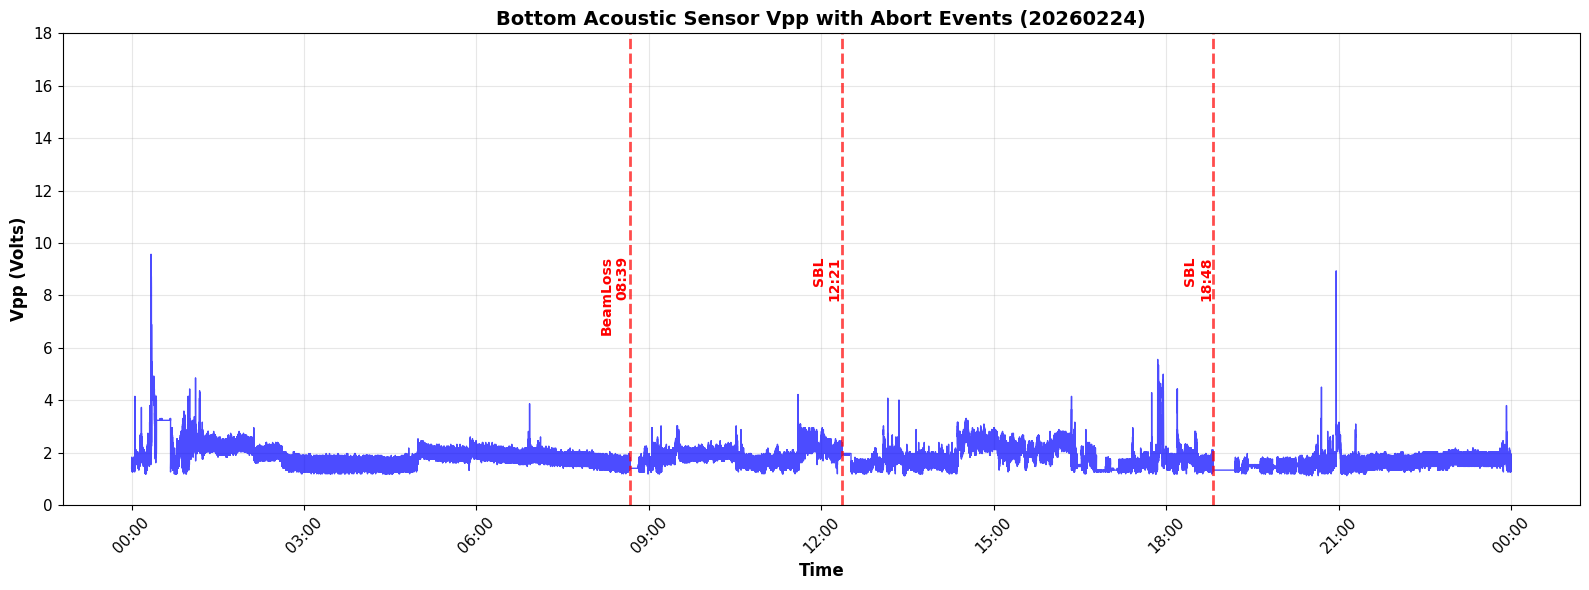


✓ Plotted daily acoustic signal
  Vpp samples: 1728452
  Abort events marked: 3


In [25]:
# Load abort event data
import subprocess
import sys

# Ensure openpyxl is installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])

abort_data_path = "/Users/xylu/Desktop/Data/Complete_LER_Event_Data_Analysis_Summary.xlsx"

print("="*60)
print("Loading Abort Event Data")
print("="*60)

if os.path.exists(abort_data_path):
    # Load abort data from Excel file
    abort_df = pd.read_excel(abort_data_path)
    
    # Parse the Time column (format: "M/D/YY H:MM" or "M/D/YY HH:MM")
    # Convert to datetime
    abort_df['abort_datetime'] = pd.to_datetime(abort_df['Time'], format='%m/%d/%y %H:%M')
    
    print(f"✓ Loaded {len(abort_df)} abort events")
    print(f"  Date range: {abort_df['abort_datetime'].min()} to {abort_df['abort_datetime'].max()}")
    print(f"  Columns: {list(abort_df.columns)}")
    
    # Filter abort events for the current date
    abort_date_start = datetime.strptime(date_str, "%Y%m%d").replace(hour=0, minute=0, second=0)
    abort_date_end = abort_date_start + timedelta(days=1)
    
    abort_mask = (abort_df['abort_datetime'] >= abort_date_start) & (abort_df['abort_datetime'] < abort_date_end)
    abort_today = abort_df[abort_mask].copy()
    
    print(f"\n✓ Found {len(abort_today)} abort event(s) on {date_str}")
    
    if len(abort_today) > 0:
        print("\nAbort Events:")
        for idx, row in abort_today.iterrows():
            print(f"  {row['abort_datetime'].strftime('%Y-%m-%d %H:%M:%S')} - {row['Category']} - {row['Origin']}")
    else:
        print("  No abort events found for this date")
else:
    print(f"⚠ Abort data file not found: {abort_data_path}")
    abort_df = None
    abort_today = None
    
# Plot daily acoustic signal with abort events marked
if filtered_df is not None and len(filtered_df) > 0:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Plot Vpp
    ax.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], 
            linewidth=1, color='blue', alpha=0.7, label='CH3 Vpp')
    
    # Mark abort events if available
    if abort_today is not None and len(abort_today) > 0:
        for idx, row in abort_today.iterrows():
            abort_time = row['abort_datetime']
            # Check if abort time is within the filtered data range
            if abort_time >= filtered_df['time_datetime'].min() and abort_time <= filtered_df['time_datetime'].max():
                ax.axvline(x=abort_time, color='red', linestyle='--', linewidth=2, alpha=0.7)
                # Add label at the top of the plot
                y_pos = ax.get_ylim()[1] * 0.95
                ax.text(abort_time, y_pos, f"{row['Category']}\n{abort_time.strftime('%H:%M')}", 
                       rotation=90, verticalalignment='top', horizontalalignment='right',
                       fontsize=10, color='red', fontweight='bold')
    
    ax.set_xlabel("Time", fontsize=12, fontweight='bold')
    ax.set_ylabel("Vpp (Volts)", fontsize=12, fontweight='bold')
    ax.set_title(f"Bottom Acoustic Sensor Vpp with Abort Events ({date_str})", 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    # ax.legend(loc='upper left')
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='both', labelsize=11)
    plt.xticks(rotation=45)
    plt.ylim(0,18)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Plotted daily acoustic signal")
    print(f"  Vpp samples: {len(filtered_df)}")
    if abort_today is not None:
        print(f"  Abort events marked: {len(abort_today)}")
else:
    print("⚠ No acoustic data to plot")


🔍 DEBUG: abort_today =                   Time Origin  \
12 2026-02-24 18:48:52    LER   
13 2026-02-24 12:21:25    LER   
14 2026-02-24 08:39:55    LER   

                                               Source  I_LER [mA]  I_HER [mA]  \
12     D7 Master + Low THR VXD diamond +(CLAWS D06V1)        1546        1217   
13  D7 Master + Low THR VXD diamond + High THR VXD...        1546        1218   
14                           D7 Master +(CLAWS D06V1)        1397        1099   

      Nb  Dia(L) [mRad/s]  Dia(H) [mRad/s]  Category  \
12  2346              984               95       SBL   
13  2346              380               83       SBL   
14  2346              281               84  BeamLoss   

                       Comment / Report      abort_datetime  
12  D05_L22A D11_L19 QW3NRP/GV(D11_L03) 2026-02-24 18:48:52  
13                     D05_L22A D02_H24 2026-02-24 12:21:25  
14                       D10_L07 QW3NLP 2026-02-24 08:39:55  
   abort_today is None? False
   len(abort_to


🔍 DEBUG: abort_today =                   Time Origin  \
12 2026-02-24 18:48:52    LER   
13 2026-02-24 12:21:25    LER   
14 2026-02-24 08:39:55    LER   

                                               Source  I_LER [mA]  I_HER [mA]  \
12     D7 Master + Low THR VXD diamond +(CLAWS D06V1)        1546        1217   
13  D7 Master + Low THR VXD diamond + High THR VXD...        1546        1218   
14                           D7 Master +(CLAWS D06V1)        1397        1099   

      Nb  Dia(L) [mRad/s]  Dia(H) [mRad/s]  Category  \
12  2346              984               95       SBL   
13  2346              380               83       SBL   
14  2346              281               84  BeamLoss   

                       Comment / Report      abort_datetime  
12  D05_L22A D11_L19 QW3NRP/GV(D11_L03) 2026-02-24 18:48:52  
13                     D05_L22A D02_H24 2026-02-24 12:21:25  
14                       D10_L07 QW3NLP 2026-02-24 08:39:55  
   abort_today is None? False
   len(abort_to

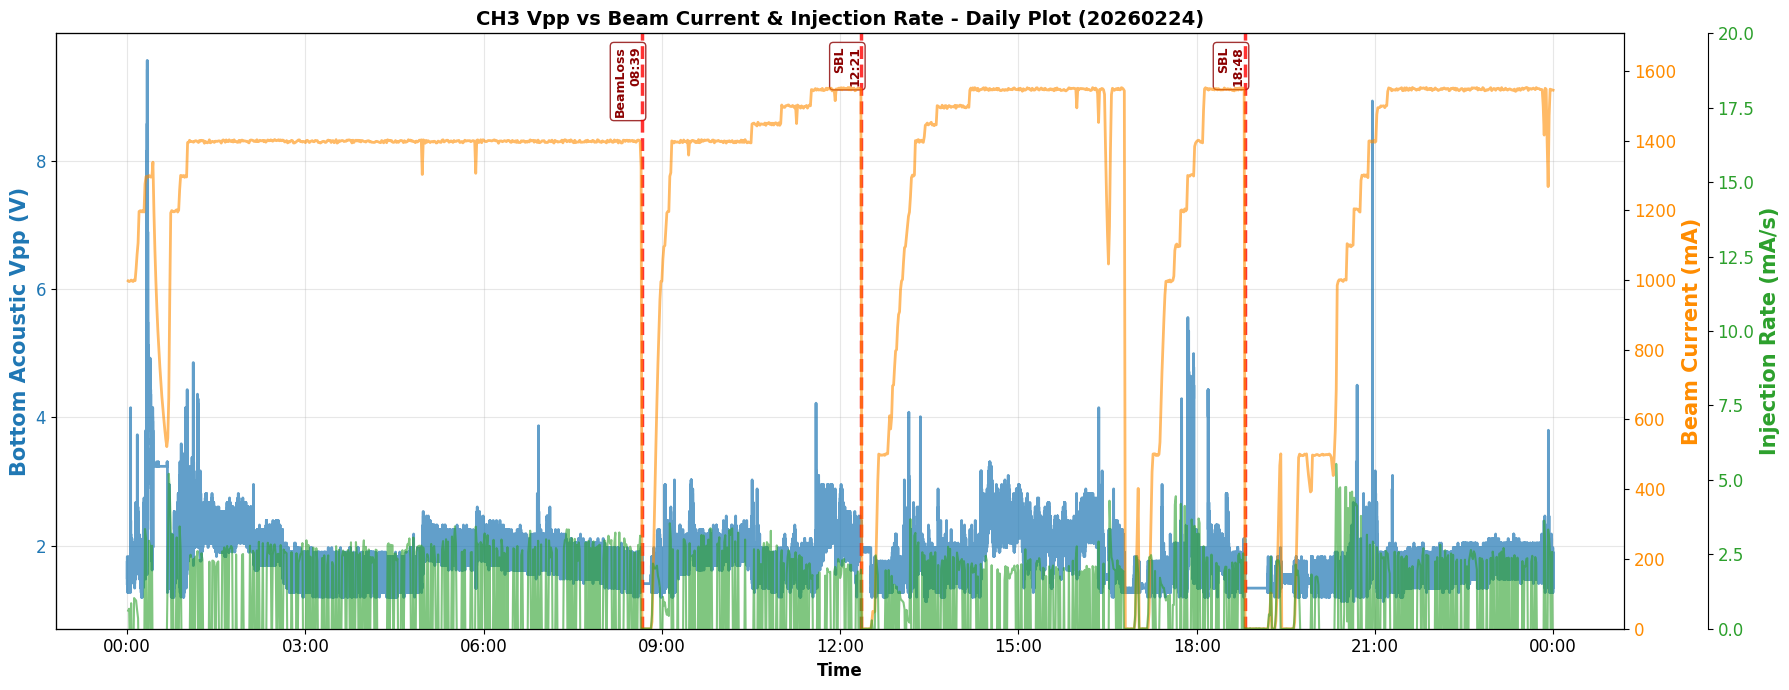


✓ Plotted daily Vpp with Beam Current, Injection Rate, and Abort Events
  Vpp samples: 1728452
  Current samples: 1441
  Injection rate samples: 1441
  Abort events marked: 3


In [27]:
# Plot daily acoustic signal with abort events AND beam current + injection rate (dual/triple-axis)
if filtered_df is not None and len(filtered_df) > 0 and machine_df_filtered is not None and len(machine_df_filtered) > 0:
    
    # Check if beam current and injection rate are available
    has_current = 'A_BM_Current_mA' in machine_df_filtered.columns
    has_inj_rate = 'A_BM_Inj_Rate_mAps' in machine_df_filtered.columns
    
    if has_current or has_inj_rate:
        # Filter out NaN values for beam current
        if has_current:
            mask_current = machine_df_filtered['A_BM_Current_mA'].notna()
            valid_times_current = machine_df_filtered.loc[mask_current, 'time_datetime']
            valid_current = machine_df_filtered.loc[mask_current, 'A_BM_Current_mA']
        
        # Filter out NaN values for injection rate
        if has_inj_rate:
            mask_inj = machine_df_filtered['A_BM_Inj_Rate_mAps'].notna()
            valid_times_inj = machine_df_filtered.loc[mask_inj, 'time_datetime']
            valid_inj_rate = machine_df_filtered.loc[mask_inj, 'A_BM_Inj_Rate_mAps']
        
        # Create figure with multiple y-axes
        fig, ax1 = plt.subplots(figsize=(18, 7))
        
        # Plot Vpp on left y-axis
        color_vpp = 'tab:blue'
        ax1.set_xlabel('Time', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Bottom Acoustic Vpp (V)', color=color_vpp, fontsize=15, fontweight='bold')
        line1 = ax1.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], 
                        linewidth=2, color=color_vpp, alpha=0.7, label='CH3 Vpp')
        ax1.tick_params(axis='y', labelcolor=color_vpp, labelsize=12)
        ax1.grid(True, alpha=0.3)
        
        # Create first right y-axis for Beam Current
        if has_current:
            ax2 = ax1.twinx()
            color_current = 'darkorange'
            ax2.set_ylabel('Beam Current (mA)', color=color_current, fontsize=15, fontweight='bold')
            line2 = ax2.plot(valid_times_current, valid_current, 
                            linewidth=2, color=color_current, marker=None, markersize=3,
                            alpha=0.6, label=f'Beam Current ({len(valid_current)} pts)')
            ax2.tick_params(axis='y', labelcolor=color_current, labelsize=12)
            ax2.set_ylim(0, valid_current.max() * 1.1)
        
        # Create second right y-axis for Injection Rate (offset from the first)
        if has_inj_rate:
            ax3 = ax1.twinx()
            # Offset the spine so it doesn't overlap with ax2
            ax3.spines['right'].set_position(('outward', 60))
            color_inj = 'tab:green'
            ax3.set_ylabel('Injection Rate (mA/s)', color=color_inj, fontsize=15, fontweight='bold')
            line3 = ax3.plot(valid_times_inj, valid_inj_rate, 
                            linewidth=1.5, color=color_inj, marker=None, markersize=4,
                            alpha=0.6, label=f'Injection Rate ({len(valid_inj_rate)} pts)')
            ax3.tick_params(axis='y', labelcolor=color_inj, labelsize=12)
            ax3.set_ylim(0,20)
        
        # Mark abort events if available (color by category: red for SBL/BeamLoss, green for others)
        print(f"\n🔍 DEBUG: abort_today = {abort_today}")
        print(f"   abort_today is None? {abort_today is None}")
        if abort_today is not None:
            print(f"   len(abort_today) = {len(abort_today)}")
        
        if abort_today is not None and len(abort_today) > 0:
            print(f"   ✓ Found {len(abort_today)} abort event(s) to plot")
            for idx, row in abort_today.iterrows():
                abort_time = row['abort_datetime']
                # Check if abort time is within the data range
                if abort_time >= filtered_df['time_datetime'].min() and abort_time <= filtered_df['time_datetime'].max():
                    # Determine color based on category
                    if row['Category'] in ['SBL', 'BeamLoss']:
                        line_color = 'red'
                        text_color = 'darkred'
                    else:
                        line_color = 'green'
                        text_color = 'darkgreen'
                    
                    ax1.axvline(x=abort_time, color=line_color, linestyle='--', linewidth=2.5, alpha=0.8, zorder=10)
                    # Add label at the top of the plot
                    y_pos = ax1.get_ylim()[1] * 0.98
                    label_text = f"{row['Category']}\n{abort_time.strftime('%H:%M')}"
                    ax1.text(abort_time, y_pos, label_text, 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           fontsize=9, color=text_color, fontweight='bold', 
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=text_color))
        
        # Add title
        ax1.set_title(f'CH3 Vpp vs Beam Current & Injection Rate - Daily Plot ({date_str})', 
                     fontsize=14, fontweight='bold')
        
        # Combine legends
        lines = line1.copy()
        labels = ['CH3 Vpp']
        
        if has_current:
            lines.extend(line2)
            labels.extend([f'Beam Current ({len(valid_current)} pts)'])
        
        if has_inj_rate:
            lines.extend(line3)
            labels.extend([f'Injection Rate ({len(valid_inj_rate)} pts)'])
        
        # ax1.legend(lines, labels, loc='upper left', fontsize=11)
        
        # Format x-axis
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.tick_params(axis='x', labelsize=12)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✓ Plotted daily Vpp with Beam Current, Injection Rate, and Abort Events")
        print(f"  Vpp samples: {len(filtered_df)}")
        if has_current:
            print(f"  Current samples: {len(valid_current)}")
        if has_inj_rate:
            print(f"  Injection rate samples: {len(valid_inj_rate)}")
        if abort_today is not None:
            print(f"  Abort events marked: {len(abort_today)}")
    else:
        print("⚠ Neither Beam Current nor Injection Rate are available in machine data")
else:
    if filtered_df is None or len(filtered_df) == 0:
        print("⚠ No acoustic Vpp data available")
    if machine_df_filtered is None or len(machine_df_filtered) == 0:
        print("⚠ No machine data available")

In [ ]:
# AUTOMATIC BATCH PROCESSING: Generate daily plots with abort events for all dates
import re

print("="*80)
print("AUTOMATIC BATCH PROCESSING - Daily Acoustic Plots with Abort Events")
print("="*80)

# Create output folder for plots
output_plot_folder = "/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots"
os.makedirs(output_plot_folder, exist_ok=True)
print(f"\nOutput folder: {output_plot_folder}")

# Find all date folders in the acoustic_vpp directory
base_path = "/Users/xylu/Desktop/Data/acoustic_vpp/"
all_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]

# Filter for folders that match YYYYMMDD format (8 digits)
date_pattern = re.compile(r'^\d{8}$')
date_folders = sorted([f for f in all_folders if date_pattern.match(f)])

print(f"\nFound {len(date_folders)} date folders to process:")
for df in date_folders:
    print(f"  - {df}")

# Load abort event data once
abort_data_path = "/Users/xylu/Desktop/Data/Complete_LER_Event_Data_Analysis_Summary.csv"
if os.path.exists(abort_data_path):
    abort_df_all = pd.read_csv(abort_data_path)
    abort_df_all['abort_datetime'] = pd.to_datetime(abort_df_all['Time'], format='%m/%d/%y %H:%M')
    print(f"\n✓ Loaded {len(abort_df_all)} total abort events")
else:
    print(f"\n⚠ Abort data file not found: {abort_data_path}")
    abort_df_all = None

print("\n" + "="*80)
print("Processing dates...")
print("="*80)

# Process each date
for date_str_auto in date_folders:
    print(f"\n[{date_str_auto}] Processing...")
    
    # Load acoustic data for this date
    date_folder_auto = os.path.join(base_path, date_str_auto)
    csv_files_auto = sorted(glob.glob(os.path.join(date_folder_auto, f"{date_str_auto}*.csv")))
    
    if len(csv_files_auto) == 0:
        print(f"  ⚠ No CSV files found, skipping")
        continue
    
    # Load and combine CSV files for this date
    all_data_auto = []
    for csv_file in csv_files_auto:
        try:
            df_temp = pd.read_csv(csv_file)
            if 'time_datetime' in df_temp.columns:
                df_temp['time_datetime'] = pd.to_datetime(df_temp['time_datetime'], format='ISO8601')
            all_data_auto.append(df_temp)
        except Exception as e:
            print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
            continue
    
    if not all_data_auto:
        print(f"  ⚠ No data loaded, skipping")
        continue
    
    # Combine all data for this date
    combined_df_auto = pd.concat(all_data_auto, ignore_index=True)
    combined_df_auto = combined_df_auto.sort_values('time_datetime').reset_index(drop=True)
    
    print(f"  ✓ Loaded {len(combined_df_auto)} samples")
    print(f"    Time range: {combined_df_auto['time_datetime'].min()} to {combined_df_auto['time_datetime'].max()}")
    
    # Filter abort events for this date
    if abort_df_all is not None:
        abort_date_start_auto = datetime.strptime(date_str_auto, "%Y%m%d").replace(hour=0, minute=0, second=0)
        abort_date_end_auto = abort_date_start_auto + timedelta(days=1)
        
        abort_mask_auto = (abort_df_all['abort_datetime'] >= abort_date_start_auto) & (abort_df_all['abort_datetime'] < abort_date_end_auto)
        abort_today_auto = abort_df_all[abort_mask_auto].copy()
        
        print(f"  ✓ Found {len(abort_today_auto)} abort event(s)")
    else:
        abort_today_auto = None
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(18, 6))
    
    # Plot Vpp
    ax.plot(combined_df_auto['time_datetime'], combined_df_auto['vpp_volts'], 
            linewidth=1, color='blue', alpha=0.7, label='CH3 Vpp')
    
    # Mark abort events if available (color by category: red for SBL/BeamLoss, green for others)
    if abort_today_auto is not None and len(abort_today_auto) > 0:
        for idx, row in abort_today_auto.iterrows():
            abort_time = row['abort_datetime']
            # Check if abort time is within the data range
            if abort_time >= combined_df_auto['time_datetime'].min() and abort_time <= combined_df_auto['time_datetime'].max():
                # Determine color based on category
                if row['Category'] in ['SBL', 'BeamLoss']:
                    line_color = 'red'
                    text_color = 'darkred'
                else:
                    line_color = 'green'
                    text_color = 'darkgreen'
                
                ax.axvline(x=abort_time, color=line_color, linestyle='--', linewidth=2.5, alpha=0.8, zorder=10)
                # Add label
                y_pos = ax.get_ylim()[1] * 0.98
                label_text = f"{row['Category']}\n{abort_time.strftime('%H:%M')}"
                ax.text(abort_time, y_pos, label_text, 
                       rotation=90, verticalalignment='top', horizontalalignment='right',
                       fontsize=9, color=text_color, fontweight='bold', 
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=text_color))
    
    ax.set_xlabel("Time", fontsize=13, fontweight='bold')
    ax.set_ylabel("Vpp (Volts)", fontsize=13, fontweight='bold')
    
    # Format date for title
    date_formatted = datetime.strptime(date_str_auto, "%Y%m%d").strftime("%Y-%m-%d")
    ax.set_title(f"Bottom Acoustic Sensor Vpp with Abort Events\n{date_formatted}", 
                 fontsize=15, fontweight='bold')
    ax.grid(True, alpha=0.3)
    # ax.legend(loc='upper left', fontsize=11)
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='both', labelsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0,18)
    
    plt.tight_layout()
    
    # Save the figure
    plot_filename = f"{date_str_auto}_daily_vpp_abort_events.png"
    plot_filepath = os.path.join(output_plot_folder, plot_filename)
    plt.savefig(plot_filepath, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ Saved plot: {plot_filename}")

print("\n" + "="*80)
print("BATCH PROCESSING COMPLETE!")
print(f"All plots saved to: {output_plot_folder}")
print("="*80)

AUTOMATIC BATCH PROCESSING - Daily Acoustic Plots with Abort Events

Output folder: /Users/xylu/Desktop/Data/acoustic_vpp/daily_plots

Found 30 date folders to process:
  - 20260126
  - 20260127
  - 20260128
  - 20260129
  - 20260130
  - 20260131
  - 20260201
  - 20260202
  - 20260203
  - 20260204
  - 20260205
  - 20260206
  - 20260207
  - 20260208
  - 20260209
  - 20260210
  - 20260211
  - 20260212
  - 20260213
  - 20260214
  - 20260215
  - 20260216
  - 20260217
  - 20260218
  - 20260219
  - 20260220
  - 20260221
  - 20260222
  - 20260223
  - 20260224

⚠ Abort data file not found: /Users/xylu/Desktop/Data/Complete_LER_Event_Data_Analysis_Summary.csv

Processing dates...

[20260126] Processing...
  ✓ Loaded 560595 samples
    Time range: 2026-01-26 16:12:46 to 2026-01-26 23:59:59.950000
  ✓ Saved plot: 20260126_daily_vpp_abort_events.png

[20260127] Processing...
  ✓ Loaded 1728512 samples
    Time range: 2026-01-27 00:00:00 to 2026-01-27 23:59:59.950000
  ✓ Saved plot: 20260127_daily_

/var/folders/_c/0_qg_9695zvdpz5_56q4wy6w0000gn/T/ipykernel_2209/665734623.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df_auto = pd.concat(all_data_auto, ignore_index=True)


  ✓ Loaded 1458083 samples
    Time range: 2026-02-02 00:00:00 to 2026-02-02 20:14:42.950000
  ✓ Saved plot: 20260202_daily_vpp_abort_events.png

[20260203] Processing...
  ✓ Loaded 1728459 samples
    Time range: 2026-02-03 00:00:00 to 2026-02-03 23:59:59.950000
  ✓ Saved plot: 20260203_daily_vpp_abort_events.png

[20260204] Processing...
  ✓ Loaded 1728487 samples
    Time range: 2026-02-04 00:00:00 to 2026-02-04 23:59:59.950000
  ✓ Saved plot: 20260204_daily_vpp_abort_events.png

[20260205] Processing...
  ✓ Loaded 1728482 samples
    Time range: 2026-02-05 00:00:00 to 2026-02-05 23:59:59.950000
  ✓ Saved plot: 20260205_daily_vpp_abort_events.png

[20260206] Processing...
  ✓ Loaded 1728494 samples
    Time range: 2026-02-06 00:00:00 to 2026-02-06 23:59:59.950000
  ✓ Saved plot: 20260206_daily_vpp_abort_events.png

[20260207] Processing...
  ✓ Loaded 1728466 samples
    Time range: 2026-02-07 00:00:00 to 2026-02-07 23:59:59.950000
  ✓ Saved plot: 20260207_daily_vpp_abort_events.png



Creating 3-panel daily plot
  ✓ Figure 1: Vpp (1728452 pts) + Beam Current (1441 pts)
  ✓ Figure 2: Inj Rate (1441 pts) + Efficiency (1363 pts)
  ✓ Figure 3: Charge (1364 pts) + Inj Rate (1441 pts)

  ✓ Marking 3 abort event(s) on all panels


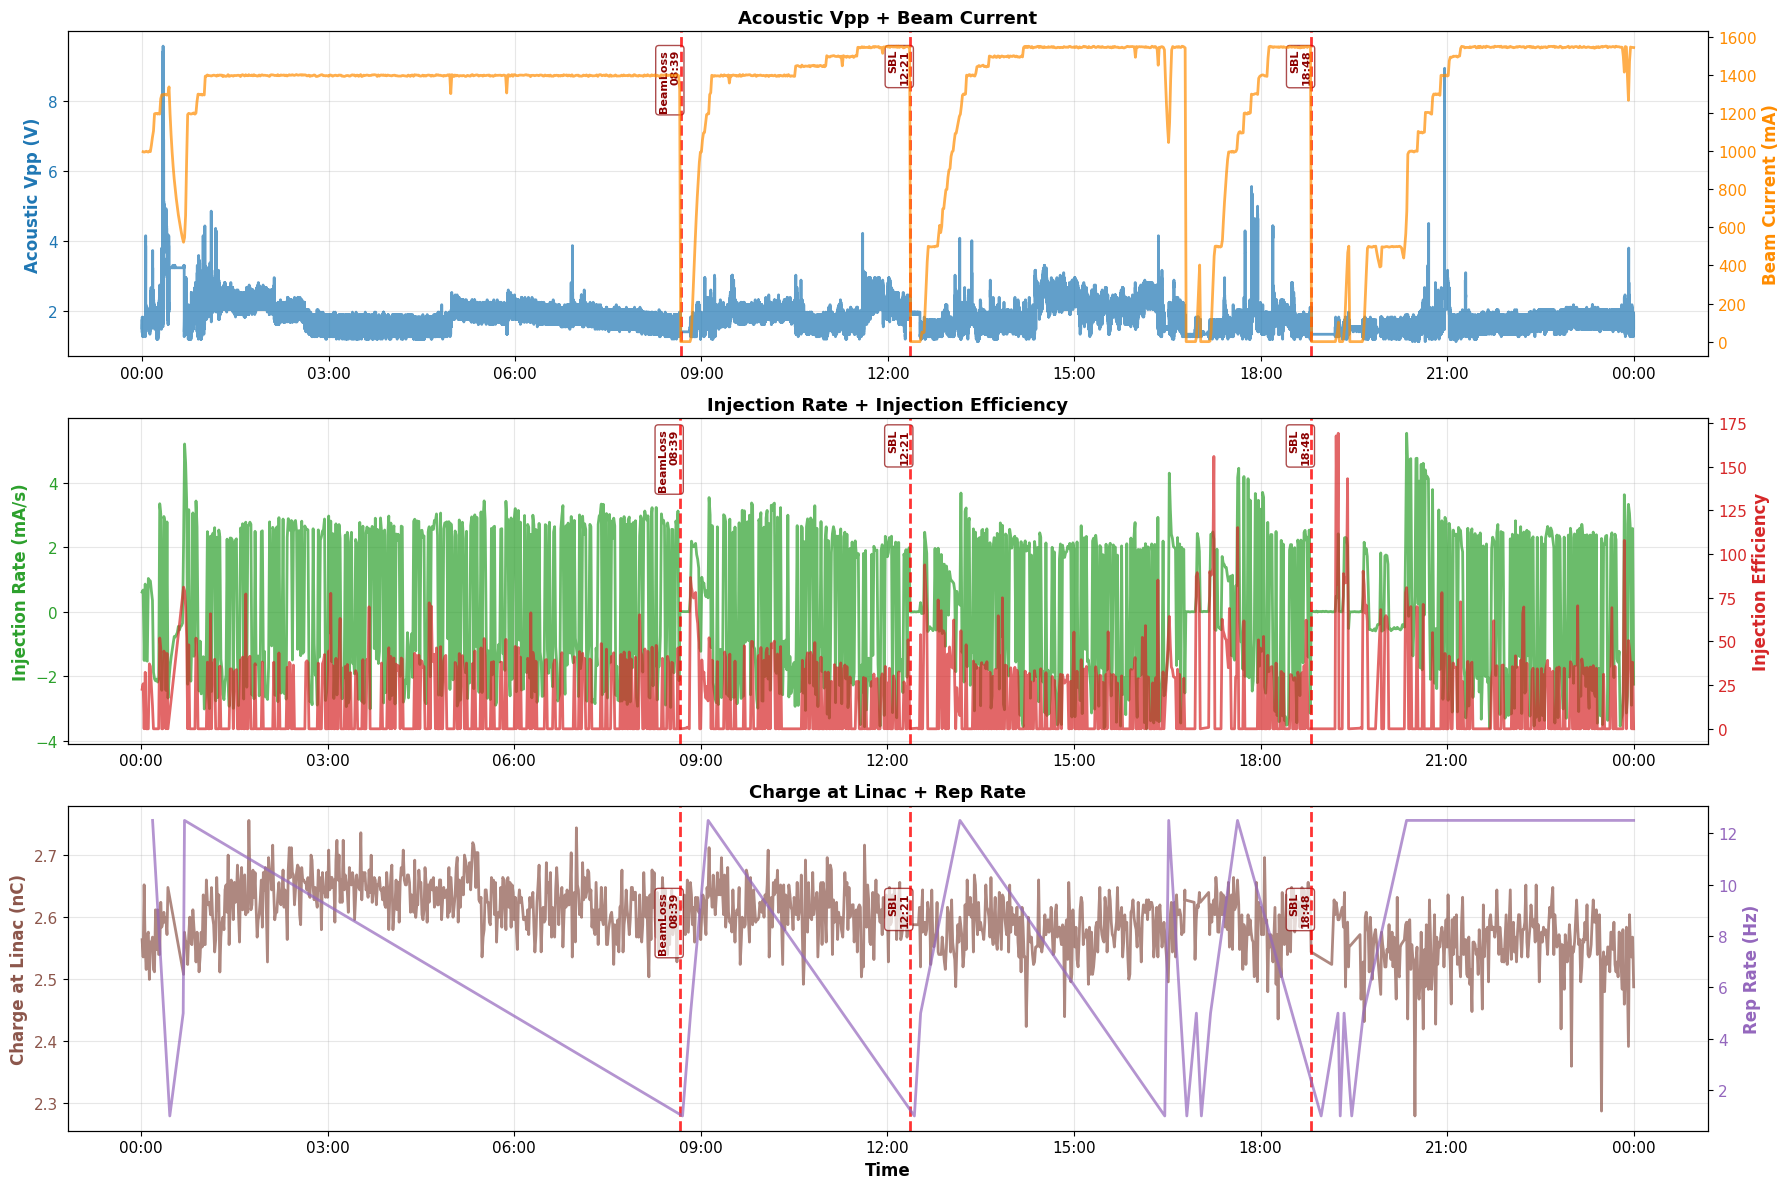


✓ Plotted 3-panel daily summary with abort events


In [ ]:
# Plot machine variables in separate dual-axis figures (3 columns)
# Figure 1: Vpp + Beam Current
# Figure 2: Injection Rate + Injection Efficiency
# Figure 3: Charge + Injection Rep Rate
if filtered_df is not None and len(filtered_df) > 0 and machine_df_filtered is not None and len(machine_df_filtered) > 0:
    
    print(f"\n{'='*70}")
    print(f"Creating 3-panel daily plot")
    print(f"{'='*70}")
    
    # Create figure with 3 subplots in a row
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 14))
    
    # Add figure title with date
    date_formatted = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    fig.suptitle(f'Daily Machine Parameters - {date_formatted}', fontsize=18, fontweight='bold', y=0.995)
    
    # ===== FIGURE 1: Vpp + Beam Current =====
    if 'A_BM_Current_mA' in machine_df_filtered.columns:
        # Get data
        mask_current = machine_df_filtered['A_BM_Current_mA'].notna()
        valid_times_current = machine_df_filtered.loc[mask_current, 'time_datetime']
        valid_current = machine_df_filtered.loc[mask_current, 'A_BM_Current_mA']
        
        # Plot Vpp on left y-axis
        color_vpp = 'tab:blue'
        ax1.set_ylabel('Bottom Acoustic Vpp (V)', color=color_vpp, fontsize=14, fontweight='bold')
        ax1.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], 
                linewidth=2.5, color=color_vpp, alpha=0.7, label='CH3 Vpp')
        ax1.tick_params(axis='y', labelcolor=color_vpp, labelsize=12)
        ax1.set_ylim(0, 18)
        ax1.grid(True, alpha=0.3)
        
        # Plot Beam Current on right y-axis
        ax1_right = ax1.twinx()
        color_current = 'darkorange'
        ax1_right.set_ylabel('Beam Current (mA)', color=color_current, fontsize=14, fontweight='bold')
        ax1_right.plot(valid_times_current, valid_current, 
                      linewidth=2.5, color=color_current, alpha=0.7, label=f'Beam Current ({len(valid_current)} pts)')
        ax1_right.tick_params(axis='y', labelcolor=color_current, labelsize=12)
        ax1_right.set_ylim(0, 1700)
        
        print(f"  ✓ Figure 1: Vpp ({len(filtered_df)} pts) + Beam Current ({len(valid_current)} pts)")
    
    # ===== FIGURE 2: Injection Rate + Injection Efficiency =====
    if 'A_BM_Inj_Rate_mAps' in machine_df_filtered.columns and 'A_INJ_Effi' in machine_df_filtered.columns:
        # Get Injection Rate
        mask_inj_rate = machine_df_filtered['A_BM_Inj_Rate_mAps'].notna()
        valid_times_inj_rate = machine_df_filtered.loc[mask_inj_rate, 'time_datetime']
        valid_inj_rate = machine_df_filtered.loc[mask_inj_rate, 'A_BM_Inj_Rate_mAps']
        
        # Get Injection Efficiency
        mask_effi = machine_df_filtered['A_INJ_Effi'].notna()
        valid_times_effi = machine_df_filtered.loc[mask_effi, 'time_datetime']
        valid_effi = machine_df_filtered.loc[mask_effi, 'A_INJ_Effi']
        
        # Plot Injection Rate on left y-axis
        color_inj_rate = 'tab:green'
        ax2.set_ylabel('Injection Rate (mA/s)', color=color_inj_rate, fontsize=14, fontweight='bold')
        ax2.plot(valid_times_inj_rate, valid_inj_rate, 
                linewidth=2.5, color=color_inj_rate, alpha=0.7, label=f'Inj Rate ({len(valid_inj_rate)} pts)')
        ax2.tick_params(axis='y', labelcolor=color_inj_rate, labelsize=12)
        ax2.set_ylim(-4, 6)
        ax2.grid(True, alpha=0.3)
        
        # Plot Injection Efficiency on right y-axis
        ax2_right = ax2.twinx()
        color_effi = 'tab:red'
        ax2_right.set_ylabel('Injection efficiency (%)', color=color_effi, fontsize=14, fontweight='bold')
        ax2_right.plot(valid_times_effi, valid_effi, 
                      linewidth=2.5, color=color_effi, alpha=0.7, label=f'Efficiency ({len(valid_effi)} pts)')
        ax2_right.tick_params(axis='y', labelcolor=color_effi, labelsize=12)
        ax2_right.set_ylim(0, 200)
        
        print(f"  ✓ Figure 2: Inj Rate ({len(valid_inj_rate)} pts) + Efficiency ({len(valid_effi)} pts)")
    
    # ===== FIGURE 3: Charge + Injection Rep Rate =====
    if 'A_Qep_BT_end_nC' in machine_df_filtered.columns and 'A_INJ_Rep_ep_Hz' in machine_df_filtered.columns:
        # Get Charge
        mask_charge = machine_df_filtered['A_Qep_BT_end_nC'].notna()
        valid_times_charge = machine_df_filtered.loc[mask_charge, 'time_datetime']
        valid_charge = machine_df_filtered.loc[mask_charge, 'A_Qep_BT_end_nC']
        
        # Get Rep Rate
        mask_rep = machine_df_filtered['A_INJ_Rep_ep_Hz'].notna()
        valid_times_rep = machine_df_filtered.loc[mask_rep, 'time_datetime']
        valid_rep = machine_df_filtered.loc[mask_rep, 'A_INJ_Rep_ep_Hz']
        
        # Plot Charge on left y-axis
        color_charge = 'tab:brown'
        ax3.set_ylabel('Charge at Linac (nC)', color=color_charge, fontsize=14, fontweight='bold')
        ax3.plot(valid_times_charge, valid_charge, 
                linewidth=2.5, color=color_charge, alpha=0.7, label=f'Charge ({len(valid_charge)} pts)')
        ax3.tick_params(axis='y', labelcolor=color_charge, labelsize=12)
        ax3.set_ylim(0, 3)
        ax3.grid(True, alpha=0.3)
        
        # Plot Injection Rep Rate on right y-axis
        ax3_right = ax3.twinx()
        color_rep = 'tab:purple'
        ax3_right.set_ylabel('Injection Rep Rate (Hz)', color=color_rep, fontsize=14, fontweight='bold')
        ax3_right.plot(valid_times_rep, valid_rep, 
                      linewidth=2.5, color=color_rep, alpha=0.7, label=f'Rep Rate ({len(valid_rep)} pts)')
        ax3_right.tick_params(axis='y', labelcolor=color_rep, labelsize=12)
        ax3_right.set_ylim(0, 15)
        
        ax3.set_xlabel('Time', fontsize=14, fontweight='bold')
        print(f"  ✓ Figure 3: Charge ({len(valid_charge)} pts) + Rep Rate ({len(valid_rep)} pts)")
    
    # Mark abort events on all subplots
    if abort_today is not None and len(abort_today) > 0:
        print(f"\n  ✓ Marking {len(abort_today)} abort event(s) on all panels")
        for idx, row in abort_today.iterrows():
            abort_time = row['abort_datetime']
            # Check if abort time is within the data range
            if abort_time >= filtered_df['time_datetime'].min() and abort_time <= filtered_df['time_datetime'].max():
                # Determine color based on category
                if row['Category'] in ['SBL', 'BeamLoss']:
                    line_color = 'red'
                    text_color = 'darkred'
                else:
                    line_color = 'green'
                    text_color = 'darkgreen'
                
                # Mark on all three axes
                for ax in [ax1, ax2, ax3]:
                    ax.axvline(x=abort_time, color=line_color, linestyle='--', linewidth=2, alpha=0.8, zorder=10)
                    y_pos = ax.get_ylim()[1] * 0.95
                    label_text = f"{row['Category']}\n{abort_time.strftime('%H:%M')}"
                    ax.text(abort_time, y_pos, label_text, 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           fontsize=9, color=text_color, fontweight='bold', 
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor=text_color))
    
    # Format x-axes
    for ax in [ax1, ax2, ax3]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', labelsize=12)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/{date_str}_machine_variables_panels.png", 
               dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Plotted 3-panel daily summary with abort events")
else:
    print("⚠ Missing required data for plots")